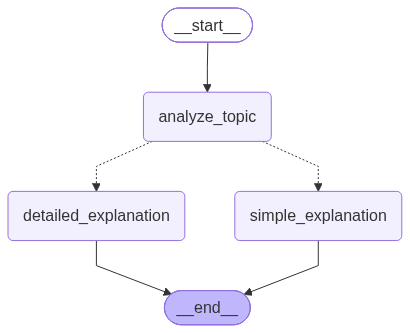

Difficulty: hard

Explanation:
### **Recursion: A Detailed Explanation**

Recursion is a fundamental concept in computer science where a **function calls itself directly or indirectly** to solve a problem by breaking it down into smaller, similar subproblems. It is a powerful technique for solving problems that can be divided into overlapping smaller instances of the same problem.

---

## **1. Key Concepts of Recursion**
### **(A) Base Case (Termination Condition)**
- The **base case** is the simplest instance of the problem that can be solved directly without further recursion.
- Without a base case, recursion leads to **infinite recursion**, causing a **stack overflow** (crashing the program).
- Example: Factorial of 0 is 1.

### **(B) Recursive Case**
- The **recursive case** breaks the problem into smaller subproblems, each calling the function again.
- Each recursive call must make progress toward the base case.

### **(C) Recursive Function**
- A function that calls itself to so

In [1]:
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, START, END
from langchain_mistralai import ChatMistralAI
from dotenv import load_dotenv

load_dotenv()

llm = ChatMistralAI(model="ministral-3b-latest")

class State(TypedDict):
    topic: str
    difficulty: str
    explanation: str

def analyze_topic(state: State):
    prompt = f"""
    Analyze the following topic and classify it as either
    'easy' or 'hard'.
    Topic: {state['topic']}
    Return only one word:
    easy
    or
    hard
    """
    response = llm.invoke(prompt)
    difficulty = response.content.strip().lower()

    if "easy" in difficulty:
        difficulty = "easy"
    else:
        difficulty = "hard"

    return {"difficulty": difficulty}

def simple_explanation(state: State):
    prompt = f"""
    Explain the following topic in very simple terms
    for a beginner:
    {state['topic']}
    """
    response = llm.invoke(prompt)
    return {"explanation": response.content}

def detailed_explanation(state: State):
    prompt = f"""
    Give a detailed explanation of the following topic.
    Include important concepts and examples:
    {state['topic']}
    """
    response = llm.invoke(prompt)
    return {"explanation": response.content}

def route_topic(state: State) -> Literal["simple_explanation", "detailed_explanation"]:
    if state["difficulty"] == "easy":
        return "simple_explanation"
    return "detailed_explanation"

graph = StateGraph(State)

graph.add_node("analyze_topic", analyze_topic)
graph.add_node("simple_explanation", simple_explanation)
graph.add_node("detailed_explanation", detailed_explanation)

graph.add_edge(START, "analyze_topic")

graph.add_conditional_edges(
    "analyze_topic",
    route_topic,
    {"simple_explanation": "simple_explanation","detailed_explanation": "detailed_explanation",}
)

graph.add_edge("simple_explanation", END)
graph.add_edge("detailed_explanation", END)

workflow = graph.compile()

result = workflow.invoke({"topic": "Recursion",})

from IPython.display import display, Image
display(Image(workflow.get_graph().draw_mermaid_png()))

print("Difficulty:", result["difficulty"])
print("\nExplanation:")
print(result["explanation"])

